# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [6]:
filename = "/content/drive/MyDrive/SUSY.csv"

VarNames = ["signal", "1_l_pT", "1_l_eta", "1_l_phi", "1_2_pT", "1_2_eta",
            "1_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
            "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

# Keep nrows=100000 so the RAM doesn't crash
df = pd.read_csv(filename, dtype='float64', names=VarNames, nrows=100000)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA).

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning).

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


In [7]:
# Machine Learning Algorithms
  # Classification: Identifying which category an object belongs to.
  # Regression: Predicting a continuous-valued attribute associated with an object.
  # Clustering: Automatic grouping of similar objects into sets.
  # Dimensionality Reduction: Reducing the number of random variables to consider.

# Linear Models
  #They are generally computationally efficient and perform well when the data is "linearly separable."
  #Common examples include Logistic Regression and Linear Discriminant Analysis (LDA).
# Linear Discriminant Analysis
  # LDA works by:
    # Projecting Data: It projects the high-dimensional input data onto a lower-dimensional space.
    # Maximizing Separability: It seeks to maximize the distance between the means of the classes while minimizing the spread (variance) within each class.
    # Efficiency: It is particularly useful for the SUSY dataset because it handles large numbers of features relatively quickly compared to more complex models like Neural Networks.

### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [8]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [9]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [10]:
Fisher.fit(X_Train,y_Train)

LinearDiscriminantAnalysis()

We can plot the output, comparing signal and background:

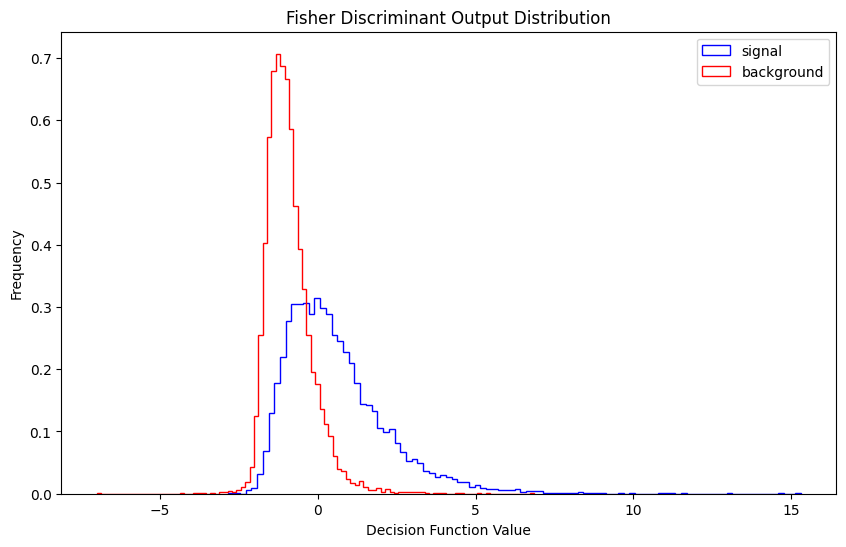

In [12]:
plt.figure(figsize=(10, 6))

total_rows = len(df)
N_Train = int(total_rows * 0.8)
Test_Sample = df.iloc[N_Train:]

Test_sig = Test_Sample[Test_Sample.signal == 1]
Test_bkg = Test_Sample[Test_Sample.signal == 0]

plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),
         bins=100, histtype="step", color="blue", label="signal", density=True)

plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),
         bins=100, histtype="step", color="red", label="background", density=True)

plt.title("Fisher Discriminant Output Distribution")
plt.xlabel("Decision Function Value")
plt.ylabel("Frequency")
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

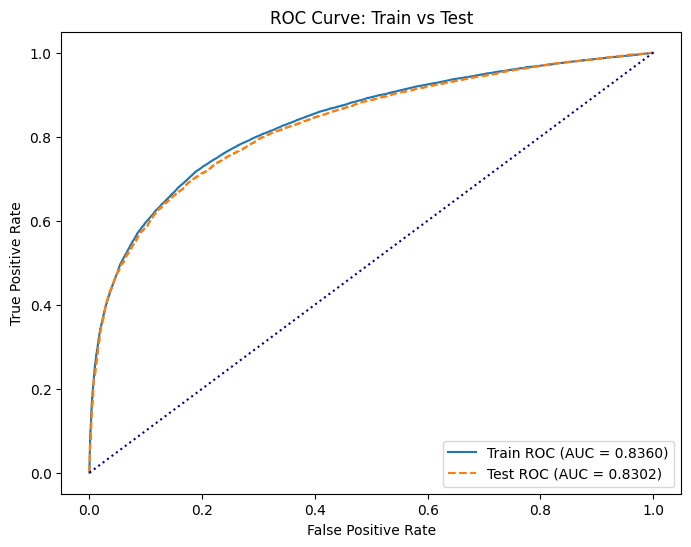

In [16]:
total_rows = len(df)
N_Train = int(total_rows * 0.8)

X_train = df[VarNames[1:]].iloc[:N_Train]
y_train = df["signal"].iloc[:N_Train]
X_test = df[VarNames[1:]].iloc[N_Train:]
y_test = df["signal"].iloc[N_Train:]

from sklearn.metrics import roc_curve, auc

y_score_train = Fisher.decision_function(X_train)
y_score_test = Fisher.decision_function(X_test)

fpr_train, tpr_train, _ = roc_curve(y_train, y_score_train)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, _ = roc_curve(y_test, y_score_test)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {roc_auc_train:.4f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {roc_auc_test:.4f})', linestyle='--')
plt.plot([0, 1], [0, 1], color='navy', linestyle=':')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Train vs Test')
plt.legend(loc="lower right")
plt.show()

In [18]:
# The ROC curves for the training and testing samples are nearly identical.
# There is no significant evidence of bias.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot.

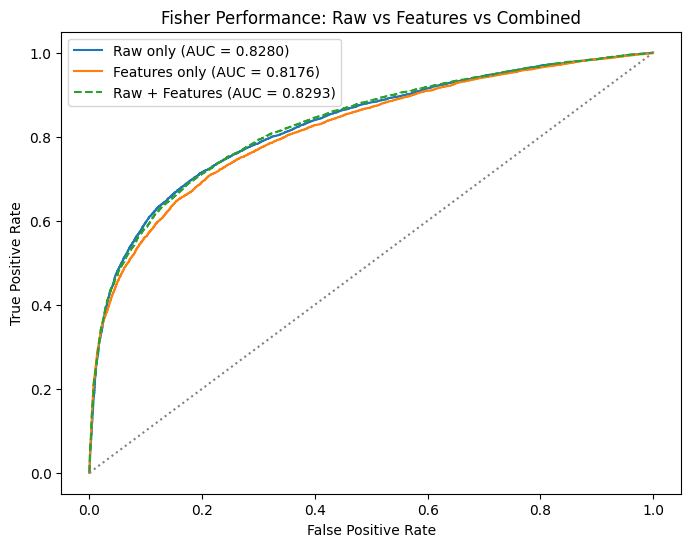

In [19]:
raw_cols = VarNames[1:9]b
feat_cols = VarNames[9:]
all_cols = VarNames[1:]

Fisher.fit(X_train[raw_cols], y_train)
fpr_raw, tpr_raw, _ = roc_curve(y_test, Fisher.decision_function(X_test[raw_cols]))
auc_raw = auc(fpr_raw, tpr_raw)

Fisher.fit(X_train[feat_cols], y_train)
fpr_feat, tpr_feat, _ = roc_curve(y_test, Fisher.decision_function(X_test[feat_cols]))
auc_feat = auc(fpr_feat, tpr_feat)

Fisher.fit(X_train[all_cols], y_train)
fpr_all, tpr_all, _ = roc_curve(y_test, Fisher.decision_function(X_test[all_cols]))
auc_all = auc(fpr_all, tpr_all)

plt.figure(figsize=(8, 6))
plt.plot(fpr_raw, tpr_raw, label=f'Raw only (AUC = {auc_raw:.4f})')
plt.plot(fpr_feat, tpr_feat, label=f'Features only (AUC = {auc_feat:.4f})')
plt.plot(fpr_all, tpr_all, label=f'Raw + Features (AUC = {auc_all:.4f})', linestyle='--')
plt.plot([0, 1], [0, 1], linestyle=':', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Fisher Performance: Raw vs Features vs Combined')
plt.legend()
plt.show()

In [ ]:
# All three ROC curves are grouped together indicating that the Fisher Discriminant is effective regardless of the feature set used

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [20]:
# Logistic regression
# Decision Trees
# Random forests

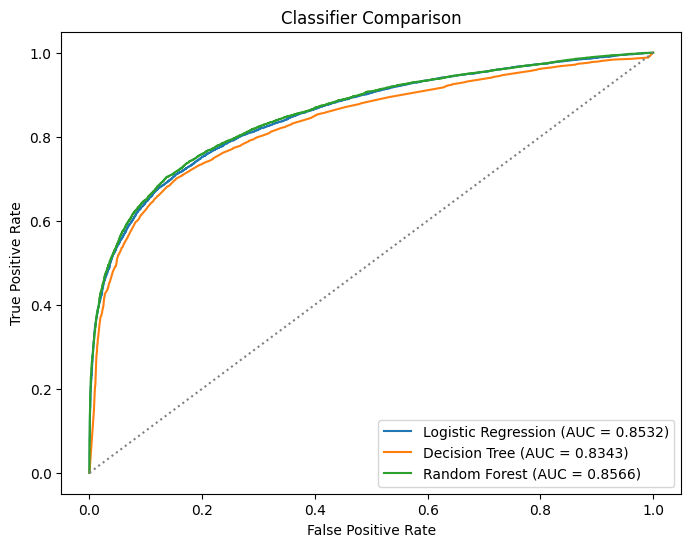

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

def compare_classifier(clf, X_tr, y_tr, X_te, y_te):
    clf.fit(X_tr, y_tr)

    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_te)[:, 1]
    else:
        y_score = clf.decision_function(X_te)

    fpr, tpr, _ = roc_curve(y_te, y_score)
    return fpr, tpr, auc(fpr, tpr)

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=10, max_depth=10)
}

plt.figure(figsize=(8, 6))
for name, clf in classifiers.items():
    fpr, tpr, roc_auc = compare_classifier(clf, X_train, y_train, X_test, y_test)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], linestyle=':', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Classifier Comparison')
plt.legend()
plt.show()

In [22]:
best_clf = classifiers["Random Forest"]
y_pred = best_clf.predict(X_test)

N_S = np.sum((y_pred == 1) & (y_test == 1))
N_B = np.sum((y_pred == 1) & (y_test == 0))
sigma_S = N_S / np.sqrt(N_S + N_B)

print(f"Number of Signal events correctly identified (N_S): {N_S}")
print(f"Number of Background events misidentified (N_B): {N_B}")
print(f"Maximal Significance (sigma_S): {sigma_S:.4f}")

Number of Signal events correctly identified (N_S): 6234
Number of Background events misidentified (N_B): 1343
Maximal Significance (sigma_S): 71.6173


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance.


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

y_pred = best_clf.predict(X_test)
y_score = best_clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

fpr_array, tpr_array, _ = roc_curve(y_test, y_score)
roc_auc_val = auc(fpr_array, tpr_array)

N_S = np.sum((y_pred == 1) & (y_test == 1))
N_B = np.sum((y_pred == 1) & (y_test == 0))
sigma_S = N_S / np.sqrt(N_S + N_B)

metrics_data = {
    "Metric": ["Accuracy", "Precision", "Recall (TPR)", "F1 Score", "AUC", "Maximal Significance"],
    "Value": [f"{acc:.4f}", f"{prec:.4f}", f"{rec:.4f}", f"{f1:.4f}", f"{roc_auc_val:.4f}", f"{sigma_S:.4f}"]
}

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))

              Metric   Value
            Accuracy  0.7893
           Precision  0.8228
        Recall (TPR)  0.6848
            F1 Score  0.7474
                 AUC  0.8566
Maximal Significance 71.6173
